<a href="https://colab.research.google.com/github/deepika-3/Deepa/blob/main/Grapg_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain langchain-community sentence-transformers networkx matplotlib faiss-cpu langchain-text-splitters

In [ ]:
!pip install pypdf

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import faiss
import json

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings

In [ ]:
!pip install numpy
!pip install faiss-cpu

In [ ]:


loader = PyPDFLoader("//content/karna_story_with_data.pdf")
docs = loader.load()

In [ ]:
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)
chunks = splitter.split_documents(docs)

texts = [c.page_content for c in chunks]

In [ ]:
embed_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

embeddings = embed_model.embed_documents(texts)

/tmp/ipykernel_6291/1936052506.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embed_model = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
dim = len(embeddings[0])
index = faiss.IndexFlatL2(dim)
index.add(np.array(embeddings).astype('float32'))

In [ ]:
def vector_search(query, k=3):
    q_embed = embed_model.embed_query(query)
    D, I = index.search(np.array([q_embed]).astype('float32'), k)
    return [texts[i] for i in I[0]]

In [ ]:
G = nx.Graph()

In [ ]:
def extract_entities(text):
    entities = []

    keywords = ["Karna", "Kunti", "Arjuna", "Duryodhana", "Surya"]

    for k in keywords:
        if k.lower() in text.lower():
            entities.append(k)

    return list(set(entities))

In [ ]:
for text in texts:
    ents = extract_entities(text)

    for e in ents:
        G.add_node(e)

    for i in range(len(ents)):
        for j in range(i+1, len(ents)):
            G.add_edge(ents[i], ents[j])

In [ ]:
def plot_graph(sub_nodes=None):
    plt.figure()

    if sub_nodes:
        subG = G.subgraph(sub_nodes)
    else:
        subG = G

    pos = nx.spring_layout(subG)
    nx.draw(subG, pos, with_labels=True)
    plt.show()

In [ ]:
def ask_question(query):

    # Step 1: vector search
    docs = vector_search(query)
    combined_text = "\n".join(docs) # Combine for numerical data extraction

    # Step 2: extract entities from query
    ents = extract_entities(query)

    # Step 3: plot graph for those entities
    if ents:
        plot_graph(ents)
    else:
        plot_graph()

    # Step 4: If Karna is among the entities, extract and plot numerical data
    if "Karna" in ents:
        numerical_data = extract_numerical_data(combined_text)
        if numerical_data: # Only plot if there's data to plot
            plot_data(numerical_data)

    # Step 5: return answer (simple)
    return combined_text

In [ ]:
import matplotlib.pyplot as plt

def plot_data(data):
    keys = list(data.keys())
    values = list(data.values())

    plt.figure()
    plt.bar(keys, values)
    plt.xlabel("Metrics")
    plt.ylabel("Values")
    plt.title("Extracted Numerical Data")
    plt.show()

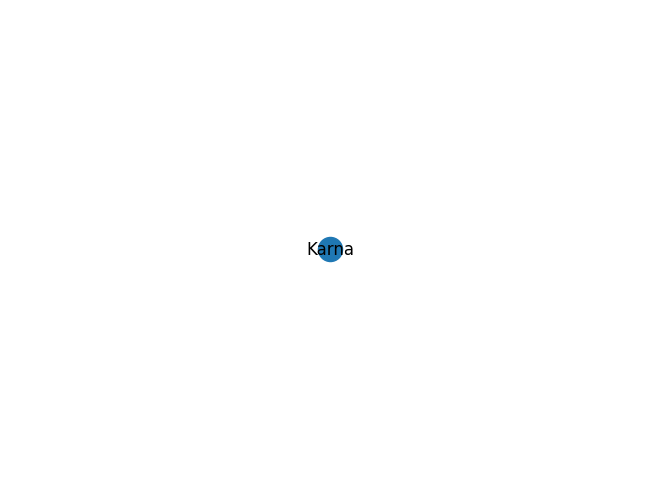

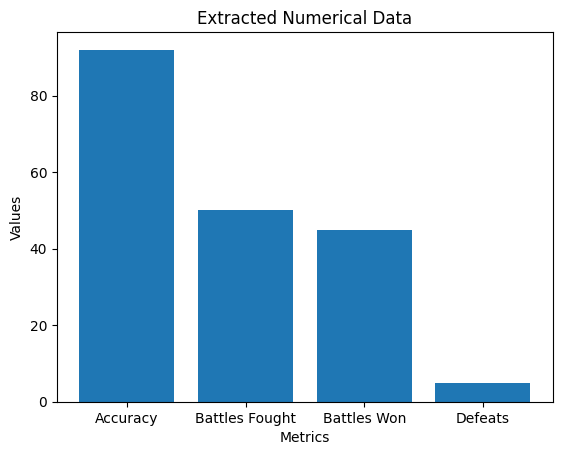

Karna was one of the greatest warriors in the Mahabharata. Key Numerical Insights about Karna:
Skill Level (out of 100): 95 Generosity Index (out of 100): 100 Loyalty Level (out of 100): 98 Archery
Accuracy (%): 92 Battles Fought: 50 Battles Won: 45 Defeats: 5 Karna was born to Kunti and the
against Arjuna, unfortunate circumstances led to his defeat. Karna’s life represents loyalty,
sacrifice, and tragedy.
Sun God (Surya). Despite being abandoned at birth, he rose to become a powerful warrior. He was
a close friend of Duryodhana, who made him the king of Anga. Karna remained loyal throughout his
life. He is known for his unmatched generosity and bravery in the Kurukshetra war. In his final battle


In [ ]:
print(ask_question("tell about Karna?"))

In [ ]:
import re

def extract_numerical_data(text):
    data = {}

    matches = re.findall(r"([A-Za-z\s%()]+):\s*(\d+)", text)

    for key, value in matches:
        clean_key = key.strip()

        # simplify names
        if "Skill" in clean_key:
            data["Skill"] = int(value)
        elif "Generosity" in clean_key:
            data["Generosity"] = int(value)
        elif "Loyalty" in clean_key:
            data["Loyalty"] = int(value)
        elif "Accuracy" in clean_key:
            data["Accuracy"] = int(value)
        elif "Battles Fought" in clean_key:
            data["Battles Fought"] = int(value)
        elif "Battles Won" in clean_key:
            data["Battles Won"] = int(value)
        elif "Defeats" in clean_key:
            data["Defeats"] = int(value)

    return data

In [ ]:
import matplotlib.pyplot as plt

def plot_data(data):
    labels = list(data.keys())
    values = list(data.values())

    plt.figure()
    plt.bar(labels, values)
    plt.xticks(rotation=45)
    plt.title("Karna Performance Metrics")
    plt.show()

{}


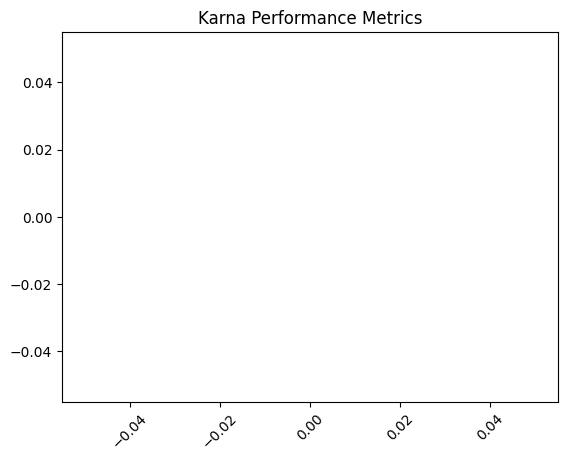

In [ ]:
text = """PASTE YOUR OUTPUT TEXT HERE"""

data = extract_numerical_data(text)

print(data)   # check first

plot_data(data)